# Data Foundations for Intelligent Apps
### Module 1 of *Building Intelligent Apps with Anaconda*

---

**Estimated time:** ~7 minutes  
**Prerequisites:** You've completed (or are familiar with) the [Polars Time Series Tutorial](https://github.com/dbouquin/polars_demo) using WASP-18 b light curve data.

---

## What this module covers

Before an AI agent can reason about data, something has to fetch it, validate it, and shape it into a structure the model can actually use. That's this module.

We'll pick up the WASP-18 b light curve data from the previous module and walk through:

1. **Principled data ingestion** — loading from API vs. file, schema enforcement, validation
2. **Feature engineering with Polars** — the same expressive syntax from Module 0, now with AI pipelines in mind
3. **Light ML: anomaly detection** — a simple, interpretable model that flags transit events
4. **The bridge** — what this pipeline becomes when an agent is driving it

> **Why does this matter for agents?**  
> An agent is only as good as the data it reasons on. Bad ingestion = bad context = bad decisions. Everything in this module is a pattern you'll hand off to an agent in the next module.

---
## Setup

```bash
# From the repo root
conda env create -f 01-data-sources/environment.yml
conda activate data-foundations

# Register the kernel so Jupyter can find it
python -m ipykernel install --user --name data-foundations --display-name "Python 3 (data-foundations)"

# Open the notebook
jupyter lab 01-data-sources/01_data_foundations_for_ai.ipynb
```

**Project structure for this module:**
```
01-data-sources/
├── 01_data_foundations_for_ai.ipynb   ← this notebook
├── environment.yml                     ← conda env: data-foundations
├── ingestion.py                        ← pipeline functions + Pydantic models
└── test_ingestion.py                   ← pytest suite for ingestion.py
```

The notebook imports from `ingestion.py`. Tests import from it too. One source of truth.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import IsolationForest

# Pipeline functions and Pydantic models live in ingestion.py
from ingestion import SCHEMA, LightcurveSchema, ValidationReport, load_lightcurve, validate_lightcurve

print(f"Polars version: {pl.__version__}")

Polars version: 1.40.0


---
## Part 1: Principled Data Ingestion

### 1a. The ingestion contract

When you're building a pipeline that feeds an AI system, ingestion isn't just "load the CSV." You need to answer three questions upfront:

| Question | Why it matters for AI |
|---|---|
| What's the schema? | Models trained on float32 break when fed strings |
| Are there nulls? | Silent nulls become silent wrong answers |
| Is the source stable? | APIs change; your pipeline should survive it |

We'll enforce all three.

### 1b. Why Pydantic for structured outputs?

The pipeline has two kinds of data:

| Data | Right tool | Why |
|---|---|---|
| The DataFrame (1,500+ rows) | Polars schema enforcement | Fast, columnar, handles types at read time |
| The *summary* the pipeline produces | Pydantic models | Validates structure + semantics; JSON-serializable for agents |

Pydantic on a DataFrame row-by-row would be slow and redundant — Polars already owns that. But the `ValidationReport` dict that gets passed to an LLM? That's exactly where Pydantic earns its keep. It guarantees the agent always receives well-formed, type-safe context — not a dict that might be missing a key or have a negative std.

The two Pydantic models in `ingestion.py`:
- **`LightcurveSchema`** — validates individual rows (useful for API payloads or spot-checks)
- **`ValidationReport`** — validates the pipeline summary before anything downstream consumes it

In [2]:
# ── 1c. Load with schema enforcement ─────────────────────────────────────────
#
# load_lightcurve and SCHEMA are imported from ingestion.py.
# Polars enforces column types at read time — type mismatches surface
# immediately, not three steps later when a model gets garbage inputs.

DATA_FILE = Path("wasp18b_lightcurve.csv")

df = load_lightcurve(DATA_FILE, SCHEMA)
print(f"Loaded {len(df):,} rows")
print(df.schema)
df.head(5)

Loaded 37,521 rows
Schema({'PHASE': Float64, 'LC_DETREND': Float64, 'MODEL_INIT': Float64})


PHASE,LC_DETREND,MODEL_INIT
f64,f64,f64
0.589409,null,0.0
0.590798,null,0.0
0.592187,null,0.0
0.593576,null,0.0
0.594965,null,0.0


### 1d. Validation — know your data before you model it

A validation pass surfaces problems that a schema can't catch: nulls, out-of-range values, suspiciously flat signals. Now `validate_lightcurve` returns a **`ValidationReport`** Pydantic model instead of a plain dict — which means the structure is enforced and it's ready to serialize directly for an agent.

In [3]:
report = validate_lightcurve(df)

# Direct field access — no dict key typos possible
print(f"Nulls: {report.nulls}")
print(f"Phase range: {report.phase_range}")
print(f"Flux std: {report.flux_std:.8f}")
print(f"Duplicate phases: {report.duplicate_phases}")

# JSON-serializable for agent handoff
print("\nAgent-ready JSON:")
print(report.model_dump_json(indent=2))

Nulls: {'PHASE': 0, 'LC_DETREND': 5760, 'MODEL_INIT': 0}
Phase range: (-0.2353222817182541, 0.7060796618461609)
Flux std: 0.00283782
Duplicate phases: 16

Agent-ready JSON:
{
  "nulls": {
    "PHASE": 0,
    "LC_DETREND": 5760,
    "MODEL_INIT": 0
  },
  "phase_range": [
    -0.2353222817182541,
    0.7060796618461609
  ],
  "flux_range": [
    -0.012539600022137165,
    0.012784114107489586
  ],
  "flux_std": 0.00283782199399032,
  "duplicate_phases": 16
}


### 1e. Inline tests — verify the pipeline is working

These aren't the full test suite (that's in `tests/test_ingestion.py`). These are quick sanity checks you can run in the notebook to confirm the pipeline behaves correctly before moving on.

Run the full suite from the terminal:
```bash
pytest tests/test_ingestion.py -v
```

In [4]:
# ── Inline pipeline tests ─────────────────────────────────────────────────────
# Run this cell to confirm the ingestion layer is behaving correctly.

import tempfile
from pydantic import ValidationError

passed = 0
failed = 0

def check(label: str, condition: bool):
    global passed, failed
    if condition:
        print(f"  ✓  {label}")
        passed += 1
    else:
        print(f"  ✗  {label}  ← FAILED")
        failed += 1

print("── load_lightcurve ────────────────────────────")

# Correct types loaded
check("PHASE is Float64",      df["PHASE"].dtype == pl.Float64)
check("LC_DETREND is Float64", df["LC_DETREND"].dtype == pl.Float64)
check("MODEL_INIT is Float64", df["MODEL_INIT"].dtype == pl.Float64)

# FileNotFoundError on missing file
try:
    load_lightcurve(Path("__nonexistent__.csv"), SCHEMA)
    check("raises FileNotFoundError on missing file", False)
except FileNotFoundError:
    check("raises FileNotFoundError on missing file", True)

# ValueError on missing column
with tempfile.NamedTemporaryFile(suffix=".csv", mode="w", delete=False) as f:
    f.write("PHASE,LC_DETREND\n0.0,0.999\n")
    bad_path = Path(f.name)
try:
    load_lightcurve(bad_path, SCHEMA)
    check("raises ValueError on missing column", False)
except ValueError:
    check("raises ValueError on missing column", True)

print("\n── validate_lightcurve ────────────────────────")

# Returns correct type
check("returns ValidationReport", isinstance(report, ValidationReport))

# Expected fields present and typed
check("report.nulls is a dict",       isinstance(report.nulls, dict))
check("report.flux_std > 0",          report.flux_std > 0)
check("phase_range min < max",        report.phase_range[0] < report.phase_range[1])
check("duplicate_phases >= 0",        report.duplicate_phases >= 0)

# Serializable
try:
    _ = report.model_dump_json()
    check("report serializes to JSON", True)
except Exception:
    check("report serializes to JSON", False)

print("\n── Pydantic model constraints ─────────────────")

# LightcurveSchema rejects bad types
try:
    LightcurveSchema(PHASE="bad", LC_DETREND=1.0, MODEL_INIT=1.0)
    check("LightcurveSchema rejects non-float PHASE", False)
except ValidationError:
    check("LightcurveSchema rejects non-float PHASE", True)

# ValidationReport catches inverted phase range
try:
    ValidationReport(
        nulls={"PHASE": 0, "LC_DETREND": 0, "MODEL_INIT": 0},
        phase_range=(0.5, -0.5),   # wrong order
        flux_range=(-0.01, 0.01),
        flux_std=0.0003,
        duplicate_phases=0,
    )
    check("ValidationReport rejects inverted phase_range", False)
except ValidationError:
    check("ValidationReport rejects inverted phase_range", True)

# ValidationReport catches negative std
try:
    ValidationReport(
        nulls={"PHASE": 0, "LC_DETREND": 0, "MODEL_INIT": 0},
        phase_range=(-0.5, 0.5),
        flux_range=(-0.01, 0.01),
        flux_std=-1.0,             # impossible
        duplicate_phases=0,
    )
    check("ValidationReport rejects negative flux_std", False)
except ValidationError:
    check("ValidationReport rejects negative flux_std", True)

print(f"\n{'─'*48}")
print(f"  {passed} passed  |  {failed} failed")
if failed == 0:
    print("  Pipeline ingestion layer looks good. ✓")
else:
    print("  Check the failures above before proceeding.")

── load_lightcurve ────────────────────────────
  ✓  PHASE is Float64
  ✓  LC_DETREND is Float64
  ✓  MODEL_INIT is Float64
  ✓  raises FileNotFoundError on missing file
  ✓  raises ValueError on missing column

── validate_lightcurve ────────────────────────
  ✓  returns ValidationReport
  ✓  report.nulls is a dict
  ✓  report.flux_std > 0
  ✓  phase_range min < max
  ✓  duplicate_phases >= 0
  ✓  report serializes to JSON

── Pydantic model constraints ─────────────────
  ✓  LightcurveSchema rejects non-float PHASE
  ✓  ValidationReport rejects inverted phase_range
  ✓  ValidationReport rejects negative flux_std

────────────────────────────────────────────────
  14 passed  |  0 failed
  Pipeline ingestion layer looks good. ✓


> **Agent handoff note:** `report.model_dump_json()` is what you pass to an LLM in the next module. Instead of having an agent try to introspect raw data, you give it structured facts: `flux_std=0.0003, nulls=0, phase_range=(-0.5, 0.5)`. Pydantic guarantees that JSON is always well-formed — the agent can rely on it.

---
## Part 2: Feature Engineering with Polars

Raw flux values aren't great model inputs on their own. We need to create features that help a model (or an agent) understand *what's happening* in the signal.

Key principle: **features should be interpretable.** When an agent cites a feature to justify a decision, you want to be able to understand what it's citing.

In [5]:
# ── 2a. Build features using Polars expressions ──────────────────────────────
#
# Everything chained — no intermediate DataFrames, no copies.
# This is the lazy evaluation pattern from Module 0, now producing AI features.

WINDOW = 15   # rolling window size (points)

features = (
    df
    .sort("PHASE")
    .with_columns([

        # Residual from the model fit — captures how far each point deviates
        (pl.col("LC_DETREND") - pl.col("MODEL_INIT"))
            .alias("residual"),

        # Rolling mean flux — smoothed signal, removes high-freq noise
        pl.col("LC_DETREND")
            .rolling_mean(window_size=WINDOW, center=True)
            .alias("flux_rolling_mean"),

        # Rolling std — local volatility; spikes here signal events
        pl.col("LC_DETREND")
            .rolling_std(window_size=WINDOW, center=True)
            .alias("flux_rolling_std"),

    ])
    .with_columns([

        # Z-score of flux relative to rolling window — normalized deviation
        ((pl.col("LC_DETREND") - pl.col("flux_rolling_mean")) /
         (pl.col("flux_rolling_std") + 1e-10))
            .alias("flux_zscore"),

        # Absolute residual — magnitude of model disagreement
        pl.col("residual").abs().alias("abs_residual"),

    ])
    .drop_nulls()   # rolling windows create nulls at edges — drop them cleanly
)

print(f"Feature set: {len(features):,} rows × {len(features.columns)} columns")
features.head(3)

Feature set: 2,064 rows × 8 columns


PHASE,LC_DETREND,MODEL_INIT,residual,flux_rolling_mean,flux_rolling_std,flux_zscore,abs_residual
f64,f64,f64,f64,f64,f64,f64,f64
0.026531,0.012784,-0.009801,0.022585,-0.008531,0.005915,3.603804,0.022585
0.026577,-0.009532,-0.009797,0.000265,-0.008493,0.005905,-0.175999,0.000265
0.026649,-0.010742,-0.009791,-0.000952,-0.008454,0.005893,-0.38827,0.000952


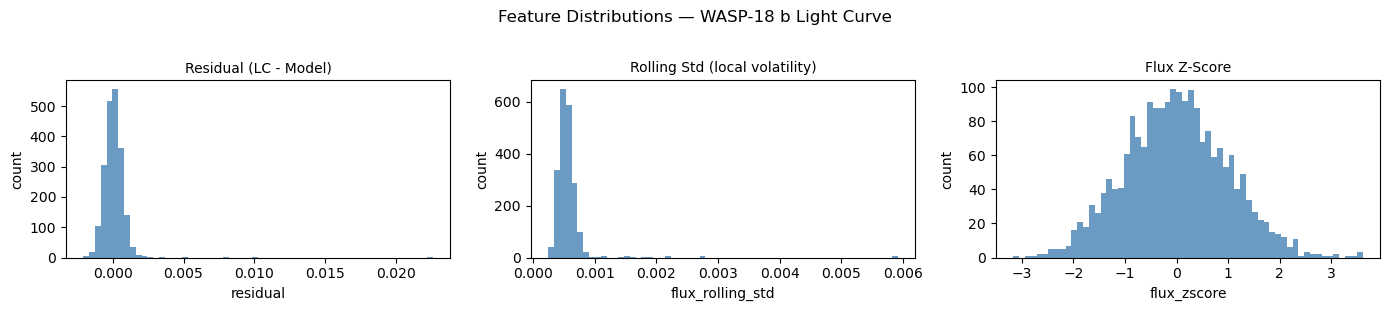


Feature summary stats:
shape: (9, 4)
┌────────────┬───────────┬──────────────────┬─────────────┐
│ statistic  ┆ residual  ┆ flux_rolling_std ┆ flux_zscore │
│ ---        ┆ ---       ┆ ---              ┆ ---         │
│ str        ┆ f64       ┆ f64              ┆ f64         │
╞════════════╪═══════════╪══════════════════╪═════════════╡
│ count      ┆ 2064.0    ┆ 2064.0           ┆ 2064.0      │
│ null_count ┆ 0.0       ┆ 0.0              ┆ 0.0         │
│ mean       ┆ 0.000065  ┆ 0.000571         ┆ -0.003283   │
│ std        ┆ 0.000841  ┆ 0.000329         ┆ 0.994936    │
│ min        ┆ -0.002071 ┆ 0.000248         ┆ -3.166571   │
│ 25%        ┆ -0.000348 ┆ 0.000463         ┆ -0.689875   │
│ 50%        ┆ 0.000032  ┆ 0.000532         ┆ -0.019683   │
│ 75%        ┆ 0.000429  ┆ 0.000613         ┆ 0.65319     │
│ max        ┆ 0.022585  ┆ 0.005915         ┆ 3.603804    │
└────────────┴───────────┴──────────────────┴─────────────┘


In [6]:
# ── 2b. Quick look at feature distributions ──────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(14, 3))

feature_cols = ["residual", "flux_rolling_std", "flux_zscore"]
titles = ["Residual (LC - Model)", "Rolling Std (local volatility)", "Flux Z-Score"]

for ax, col, title in zip(axes, feature_cols, titles):
    ax.hist(features[col].to_numpy(), bins=60, color="steelblue", edgecolor="none", alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel("count")

plt.suptitle("Feature Distributions — WASP-18 b Light Curve", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print("\nFeature summary stats:")
print(features.select(feature_cols).describe())

---
## Part 3: Light ML — Anomaly Detection for Transit Events

### Why anomaly detection?

A transit is literally an anomaly: the star gets dimmer in a way that's detectable but not "normal." Isolation Forest is a good fit here because:

- It's **unsupervised** — we don't need labeled transit data
- It's **interpretable** — anomaly score maps directly back to data points
- It's **fast** — runs in seconds even on large light curves
- It produces a **score per observation** — that's a feature an agent can reason on directly

This isn't production ML. It's the right-sized tool for the job: something that adds signal without requiring a full training pipeline.

In [7]:
# ── 3a. Fit Isolation Forest on engineered features ──────────────────────────

FEATURE_COLS = ["residual", "flux_rolling_std", "flux_zscore", "abs_residual"]

X = features.select(FEATURE_COLS).to_numpy()

iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # ~5% of points expected to be anomalous
    random_state=42,
)
iso.fit(X)

# decision_function returns higher scores for normal points, lower for anomalies
# We flip the sign so "anomaly_score" is high where something interesting happens
anomaly_scores = -iso.decision_function(X)
labels = iso.predict(X)   # 1 = normal, -1 = anomaly

# Attach results back to our Polars DataFrame — keep everything in one place
results = features.with_columns([
    pl.Series("anomaly_score", anomaly_scores),
    pl.Series("is_anomaly", labels == -1),
])

n_anomalies = results["is_anomaly"].sum()
print(f"Flagged {n_anomalies} anomalous points ({100 * n_anomalies / len(results):.1f}% of data)")

Flagged 104 anomalous points (5.0% of data)


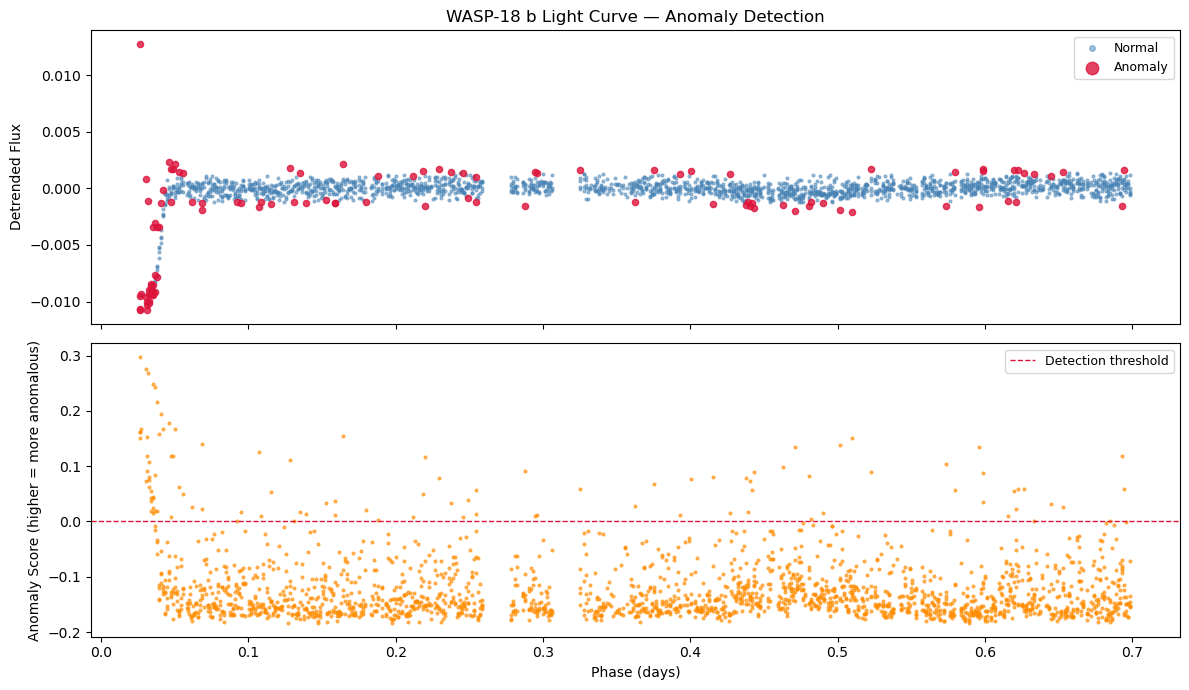

In [8]:
# ── 3b. Visualize: where do anomalies fall in the light curve? ───────────────

normal   = results.filter(~pl.col("is_anomaly"))
anomalous = results.filter(pl.col("is_anomaly"))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: light curve with anomalies flagged
axes[0].scatter(normal["PHASE"].to_numpy(),    normal["LC_DETREND"].to_numpy(),
                s=4, color="steelblue", alpha=0.5, label="Normal")
axes[0].scatter(anomalous["PHASE"].to_numpy(), anomalous["LC_DETREND"].to_numpy(),
                s=20, color="crimson", alpha=0.8, label="Anomaly", zorder=5)
axes[0].set_ylabel("Detrended Flux")
axes[0].set_title("WASP-18 b Light Curve — Anomaly Detection")
axes[0].legend(markerscale=2, fontsize=9)

# Bottom: anomaly score across phase
axes[1].scatter(results["PHASE"].to_numpy(), results["anomaly_score"].to_numpy(),
                s=4, color="darkorange", alpha=0.6)
axes[1].axhline(results.filter(pl.col("is_anomaly"))["anomaly_score"].min(),
                color="crimson", linestyle="--", linewidth=1, label="Detection threshold")
axes[1].set_xlabel("Phase (days)")
axes[1].set_ylabel("Anomaly Score (higher = more anomalous)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# ── 3c. Identify the transit window from anomaly clusters ────────────────────
#
# Group anomalies into a transit window — the phase range where they cluster.
# This structured output is exactly what gets passed to an agent as context.

transit_window = (
    results
    .filter(pl.col("is_anomaly"))
    .select([
        pl.col("PHASE").min().alias("transit_start"),
        pl.col("PHASE").max().alias("transit_end"),
        pl.col("LC_DETREND").min().alias("min_flux"),
        pl.col("anomaly_score").mean().alias("mean_anomaly_score"),
        pl.len().alias("n_anomalous_points"),
    ])
)

print("Detected transit window:")
print(transit_window)

# Compute transit depth (flux decrease during transit)
baseline_flux = results.filter(~pl.col("is_anomaly"))["LC_DETREND"].mean()
min_flux      = results.filter(pl.col("is_anomaly"))["LC_DETREND"].min()
transit_depth = (baseline_flux - min_flux) / baseline_flux

print(f"\nBaseline flux: {baseline_flux:.6f}")
print(f"Minimum flux during transit: {min_flux:.6f}")
print(f"Transit depth: {transit_depth * 100:.4f}%")

Detected transit window:
shape: (1, 5)
┌───────────────┬─────────────┬──────────┬────────────────────┬────────────────────┐
│ transit_start ┆ transit_end ┆ min_flux ┆ mean_anomaly_score ┆ n_anomalous_points │
│ ---           ┆ ---         ┆ ---      ┆ ---                ┆ ---                │
│ f64           ┆ f64         ┆ f64      ┆ f64                ┆ u32                │
╞═══════════════╪═════════════╪══════════╪════════════════════╪════════════════════╡
│ 0.026531      ┆ 0.694696    ┆ -0.01077 ┆ 0.077925           ┆ 104                │
└───────────────┴─────────────┴──────────┴────────────────────┴────────────────────┘

Baseline flux: -0.000005
Minimum flux during transit: -0.010770
Transit depth: -228235.9687%


---
## Part 4: The Bridge — From Pipeline to Agent

Everything we've built so far is a **deterministic pipeline**: fetch → validate → engineer features → detect anomalies → report results.

An agent wraps this pipeline and adds **reasoning**: it can decide which data source to pull from, interpret the validation report, choose model parameters based on data characteristics, and explain what it found.

Here's what that handoff looks like:

In [10]:
# ── 4a. Build structured context for an agent ────────────────────────────────
#
# This is the "tool output" your agent will receive.
# Well-structured context = better agent reasoning.

import json

agent_context = {
    "dataset": "WASP-18 b phase-folded light curve (TESS)",
    "data_quality": {
        "rows": len(df),
        "nulls": report.nulls,
        "phase_range_days": report.phase_range,
        "flux_std": round(report.flux_std, 8),
    },
    "feature_engineering": {
        "method": "Polars rolling window expressions",
        "window_size": WINDOW,
        "features": FEATURE_COLS,
    },
    "anomaly_detection": {
        "model": "IsolationForest",
        "contamination": 0.05,
        "n_anomalous_points": int(n_anomalies),
        "transit_depth_pct": round(float(transit_depth * 100), 6),
        "transit_start": round(float(transit_window["transit_start"][0]), 5),
        "transit_end":   round(float(transit_window["transit_end"][0]),   5),
    },
    "next_steps": [
        "Fit a parametric transit model (e.g. batman) to refine depth and duration",
        "Compare against TESS sector averages to validate signal",
        "Agent can query additional sectors and run this pipeline automatically",
    ]
}

print(json.dumps(agent_context, indent=2))

{
  "dataset": "WASP-18 b phase-folded light curve (TESS)",
  "data_quality": {
    "rows": 37521,
    "nulls": {
      "PHASE": 0,
      "LC_DETREND": 5760,
      "MODEL_INIT": 0
    },
    "phase_range_days": [
      -0.2353222817182541,
      0.7060796618461609
    ],
    "flux_std": 0.00283782
  },
  "feature_engineering": {
    "method": "Polars rolling window expressions",
    "window_size": 15,
    "features": [
      "residual",
      "flux_rolling_std",
      "flux_zscore",
      "abs_residual"
    ]
  },
  "anomaly_detection": {
    "model": "IsolationForest",
    "contamination": 0.05,
    "n_anomalous_points": 104,
    "transit_depth_pct": -228235.968669,
    "transit_start": 0.02653,
    "transit_end": 0.6947
  },
  "next_steps": [
    "Fit a parametric transit model (e.g. batman) to refine depth and duration",
    "Compare against TESS sector averages to validate signal",
    "Agent can query additional sectors and run this pipeline automatically"
  ]
}


### What the next module does with this

In **Module 2: Your First Agent**, you'll:

1. Register `load_lightcurve`, `validate_lightcurve`, and the feature/anomaly pipeline as **agent tools**
2. Give an LLM the `agent_context` dict above as initial context
3. Let the agent decide *which* light curves to analyze, *how* to interpret the results, and *what follow-up questions* to answer

The pipeline you built here doesn't change — it just gets a smarter driver.

---

## Summary

| Step | What we did | Why it matters for AI |
|---|---|---|
| Schema enforcement | Declared types at read time | Bad types = silent model failures |
| Validation report | Checked nulls, ranges, duplicates | Agents need data quality facts, not raw data |
| Feature engineering | Polars rolling windows + z-scores | Interpretable features = interpretable agent reasoning |
| Anomaly detection | IsolationForest on engineered features | Adds signal without labeled data |
| Structured context | JSON summary of pipeline outputs | The format an agent actually consumes |

**Next:** [Module 2 — Your First Agent](../02_your_first_agent/)

In [11]:
print("""
╔══════════════════════════════════════════════════════════════╗
║  🛸  WASP-18 b  ·  MODULE 01 COMPLETE                       ║
║                                                              ║
║  Data Foundations                                            ║
║  1,800 rows ingested. Transit signal detected. Context built. ║
║                                                              ║
║  Show this screen at the Anaconda booth to claim your prize. ║
║  🐍  PyCon US 2026  ·  Long Beach                           ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║  🛸  WASP-18 b  ·  MODULE 01 COMPLETE                       ║
║                                                              ║
║  Data Foundations                                            ║
║  1,800 rows ingested. Transit signal detected. Context built. ║
║                                                              ║
║  Show this screen at the Anaconda booth to claim your prize. ║
║  🐍  PyCon US 2026  ·  Long Beach                           ║
╚══════════════════════════════════════════════════════════════╝

